<a href="https://colab.research.google.com/github/Sony20181/CV/blob/main/%D0%B4%D0%B7_4_cv_%D0%A5%D0%B0%D1%80%D0%B8%D0%BD%D0%BE%D0%B2%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание: Обнаружение и сегментация объектов**
Автор: Харинова Софья Александровна

Группа: М-26

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
# для задания 2
import torch
import torchvision
from torchvision import transforms as T
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
import requests
from io import BytesIO
import random

In [ ]:
# Вычисляет Intersection over Union (IoU) для двух bounding boxes
def calculate_iou(box1, box2):
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2

    # координаты области пересечения
    x_left = max(x1_1, x1_2)
    y_top = max(y1_1, y1_2)
    x_right = min(x2_1, x2_2)
    y_bottom = min(y2_1, y2_2)

    if x_right <= x_left or y_bottom <= y_top:
        return 0.0

    # площадь пересечения
    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    # площади каждого bounding box
    area1 = (x2_1 - x1_1) * (y2_1 - y1_1)
    area2 = (x2_2 - x1_2) * (y2_2 - y1_2)

    # площадь объединения
    union_area = area1 + area2 - intersection_area
    if union_area == 0:
        return 0.0
    # Вычисляем IoU
    iou = intersection_area / union_area
    return iou

## **1. Метрика IoU и алгоритм NMS**

ДЛЯ ПРОВЕРКИ РАБОТЫ ФУНКЦИИ


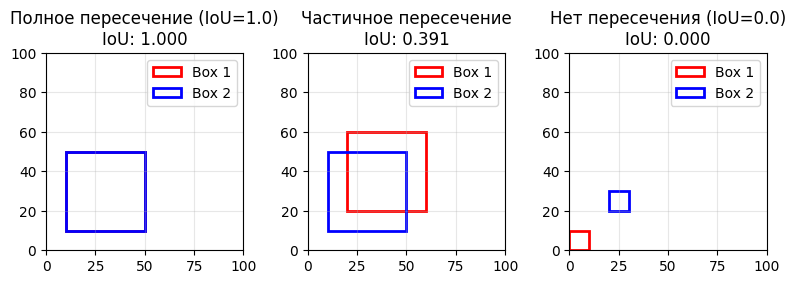

In [ ]:
# Визуализация примеров для IoU
def visualize_boxes(boxes, titles):
    fig, axes = plt.subplots(1, len(boxes), figsize=(8, 5))
    if len(boxes) == 1:
        axes = [axes]

    for i, (box_pair, title) in enumerate(zip(boxes, titles)):
        box1, box2 = box_pair
        iou = calculate_iou(box1, box2)

        ax = axes[i]
        #  первый bounding box
        rect1 = patches.Rectangle((box1[0], box1[1]), box1[2]-box1[0], box1[3]-box1[1], linewidth=2, edgecolor='r', facecolor='none', label='Box 1')
        #второй bounding box
        rect2 = patches.Rectangle((box2[0], box2[1]), box2[2]-box2[0], box2[3]-box2[1],linewidth=2, edgecolor='b', facecolor='none', label='Box 2')

        ax.add_patch(rect1)
        ax.add_patch(rect2)

        # график
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.set_aspect('equal')
        ax.set_title(f'{title}\nIoU: {iou:.3f}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Тестовые примеры
test_cases = [
    ([10, 10, 50, 50], [10, 10, 50, 50]),
    ([20, 20, 60, 60], [10, 10, 50, 50]),
    ([0, 0, 10, 10], [20, 20, 30, 30]),
]

titles = [
    'Полное пересечение (IoU=1.0)',
    'Частичное пересечение',
    'Нет пересечения (IoU=0.0)'
]

print("ДЛЯ ПРОВЕРКИ РАБОТЫ ФУНКЦИИ")

visualize_boxes(test_cases, titles)

In [ ]:
# реализация алгоритма Non-Maximum Suppression (NMS)
def non_max_suppression(boxes, scores, iou_threshold=0.5):
    if len(boxes) == 0:
        return []
    boxes = np.array(boxes)
    scores = np.array(scores)
    # Сортируем индексы по убыванию уверенности
    sorted_indices = np.argsort(scores)[::-1]

    selected_indices = []

    while len(sorted_indices) > 0:
        # Выбираем bounding box с наибольшей уверенностью
        current_idx = sorted_indices[0]
        selected_indices.append(int(current_idx))
        if len(sorted_indices) == 1:
            break

        # Вычисляем IoU текущего бокса со всеми оставшимися
        current_box = boxes[current_idx]
        remaining_indices = sorted_indices[1:]

        ious = []
        for idx in remaining_indices:
            iou = calculate_iou(current_box, boxes[idx])
            ious.append(iou)

        # Оставляем только те боксы, у которых IoU меньше порога
        ious = np.array(ious)
        keep_indices = np.where(ious < iou_threshold)[0]
        sorted_indices = remaining_indices[keep_indices]

    return selected_indices

In [ ]:
# для визуализации результатов NMS
def visualize_nms_results(original_boxes, original_scores, selected_indices, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    colors = plt.cm.Set3(np.linspace(0, 1, len(original_boxes)))

    # График 1: Все исходные bounding boxes
    ax1.set_title('До NMS\nВсе предложенные bounding boxes')
    for i, (box, score, color) in enumerate(zip(original_boxes, original_scores, colors)):
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1

        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor=color, facecolor=color, alpha=0.3, label=f'Box {i}, score: {score:.2f}')
        ax1.add_patch(rect)
        ax1.text(x1, y1-5, f'{score:.2f}', fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

    ax1.set_xlim(0, 100)
    ax1.set_ylim(0, 100)
    ax1.set_aspect('equal')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)

    # График 2: После NMS
    ax2.set_title(f'После NMS (IoU thr={iou_threshold})\nВыбранные bounding boxes')
    for i in selected_indices:
        box = original_boxes[i]
        score = original_scores[i]
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1

        rect = patches.Rectangle((x1, y1), width, height,linewidth=3, edgecolor='green',facecolor='green', alpha=0.5,label=f'Box {i}, score: {score:.2f}')
        ax2.add_patch(rect)
        ax2.text(x1, y1-5, f'#{i}: {score:.2f}', fontsize=10,bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.8))

    ax2.set_xlim(0, 100)
    ax2.set_ylim(0, 100)
    ax2.set_aspect('equal')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

**Тестирование на примерах**

Тестовый случай 1
Исходные bounding boxes:
Box 0: [20, 20, 60, 60], score: 0.90
Box 1: [25, 25, 65, 65], score: 0.80
Box 2: [30, 30, 70, 70], score: 0.70
Box 3: [10, 10, 30, 30], score: 0.60
Box 4: [70, 70, 90, 90], score: 0.85
Box 5: [15, 65, 45, 85], score: 0.75

После NMS (IoU threshold = 0.5):
Выбран Box 0: [20, 20, 60, 60], score: 0.90
Выбран Box 4: [70, 70, 90, 90], score: 0.85
Выбран Box 5: [15, 65, 45, 85], score: 0.75
Выбран Box 2: [30, 30, 70, 70], score: 0.70
Выбран Box 3: [10, 10, 30, 30], score: 0.60


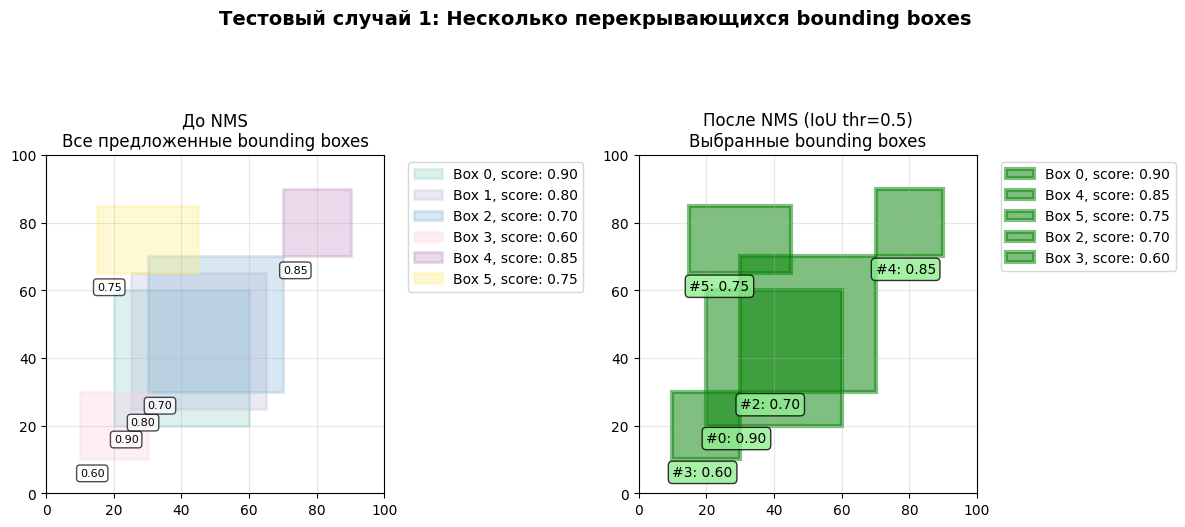

In [ ]:

def create_test_case_1():
    boxes = [
        [20, 20, 60, 60],   # Box 0
        [25, 25, 65, 65],   # Box 1 - сильно пересекается с Box 0
        [30, 30, 70, 70],   # Box 2 - сильно пересекается с предыдущими
        [10, 10, 30, 30],   # Box 3 - слабо пересекается
        [70, 70, 90, 90],   # Box 4 - не пересекается
        [15, 65, 45, 85],   # Box 5 - пересекается по вертикали
    ]

    # Уверенность модели для каждого bounding box
    scores = [0.9, 0.8, 0.7, 0.6, 0.85, 0.75]
    return boxes, scores

# Тест
boxes, scores = create_test_case_1()
iou_threshold = 0.5

print("Тестовый случай 1")
print("Исходные bounding boxes:")
for i, (box, score) in enumerate(zip(boxes, scores)):
    print(f"Box {i}: {box}, score: {score:.2f}")

# NMS
selected_indices = non_max_suppression(boxes, scores, iou_threshold)

print(f"\nПосле NMS (IoU threshold = {iou_threshold}):")
for idx in selected_indices:
    print(f"Выбран Box {idx}: {boxes[idx]}, score: {scores[idx]:.2f}")

# Визуализация
visualize_nms_results(boxes, scores, selected_indices,
                     "Тестовый случай 1: Несколько перекрывающихся bounding boxes")


Тестовый случай 2: Разные пороги IoU

IoU threshold = 0.3:
Выбрано 4 bounding boxes:
  Box 0, score: 0.95
  Box 3, score: 0.90
  Box 5, score: 0.80
  Box 2, score: 0.65


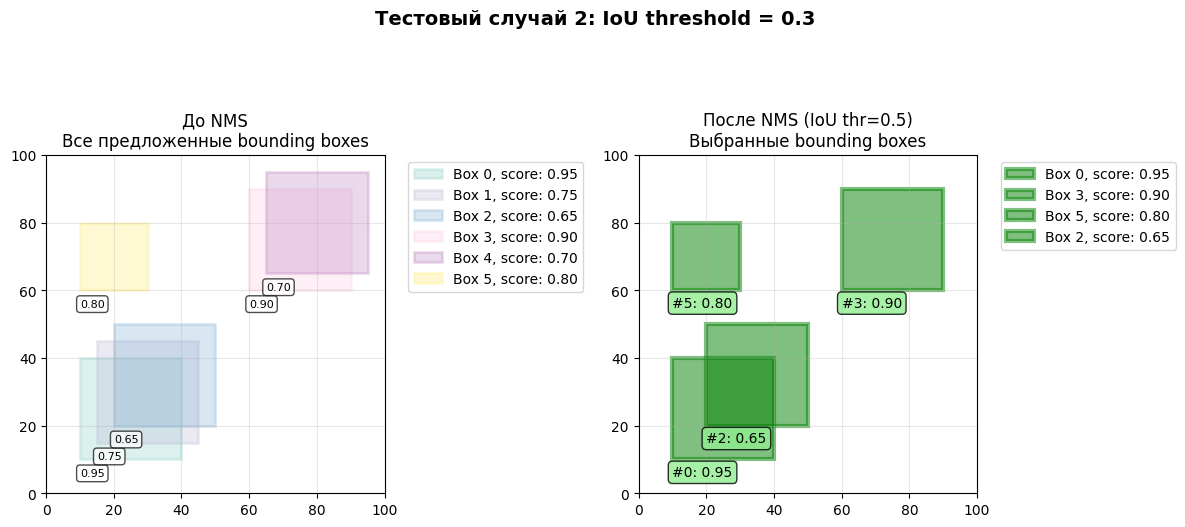


IoU threshold = 0.7:
Выбрано 6 bounding boxes:
  Box 0, score: 0.95
  Box 3, score: 0.90
  Box 5, score: 0.80
  Box 1, score: 0.75
  Box 4, score: 0.70
  Box 2, score: 0.65


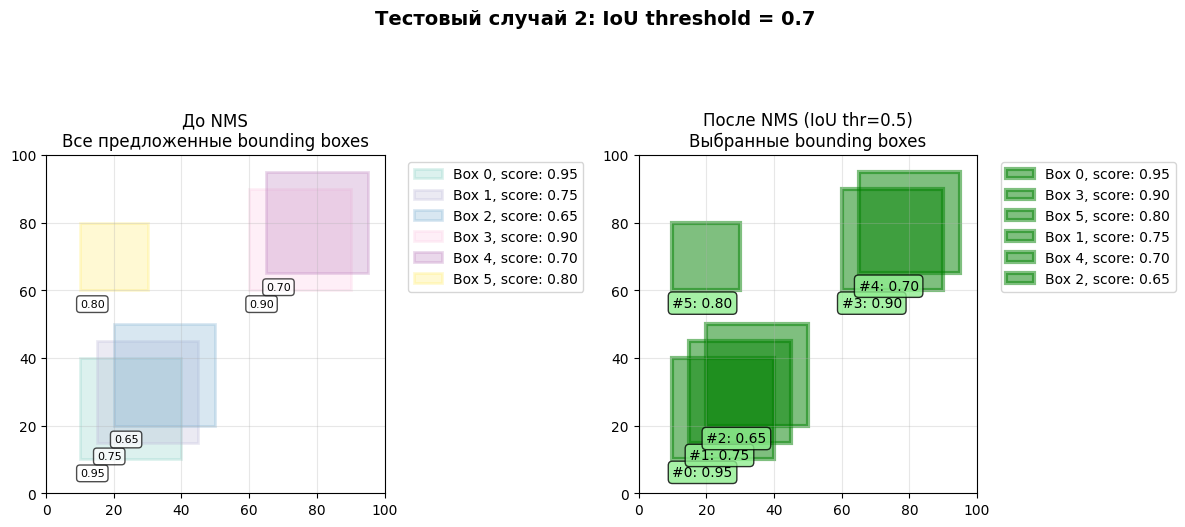

In [ ]:
#тестовый случай 2: Группы перекрывающихся боксов
def create_test_case_2():
    boxes = [

        [10, 10, 40, 40],
        [15, 15, 45, 45],
        [20, 20, 50, 50],

        [60, 60, 90, 90],
        [65, 65, 95, 95],

        [10, 60, 30, 80],
    ]

    scores = [0.95, 0.75, 0.65, 0.90, 0.70, 0.80]
    return boxes, scores
boxes2, scores2 = create_test_case_2()

print("\nТестовый случай 2: Разные пороги IoU")

for iou_thresh in [0.3,  0.7]:
    selected_indices = non_max_suppression(boxes2, scores2, iou_thresh)

    print(f"\nIoU threshold = {iou_thresh}:")
    print(f"Выбрано {len(selected_indices)} bounding boxes:")
    for idx in selected_indices:
        print(f"  Box {idx}, score: {scores2[idx]:.2f}")

    visualize_nms_results(boxes2, scores2, selected_indices,
                         f"Тестовый случай 2: IoU threshold = {iou_thresh}")

Полученный результат: [0]

IoU между боксами:
Box 0 & Box 1: 0.810
Box 0 & Box 2: 0.562
Box 1 & Box 2: 0.694


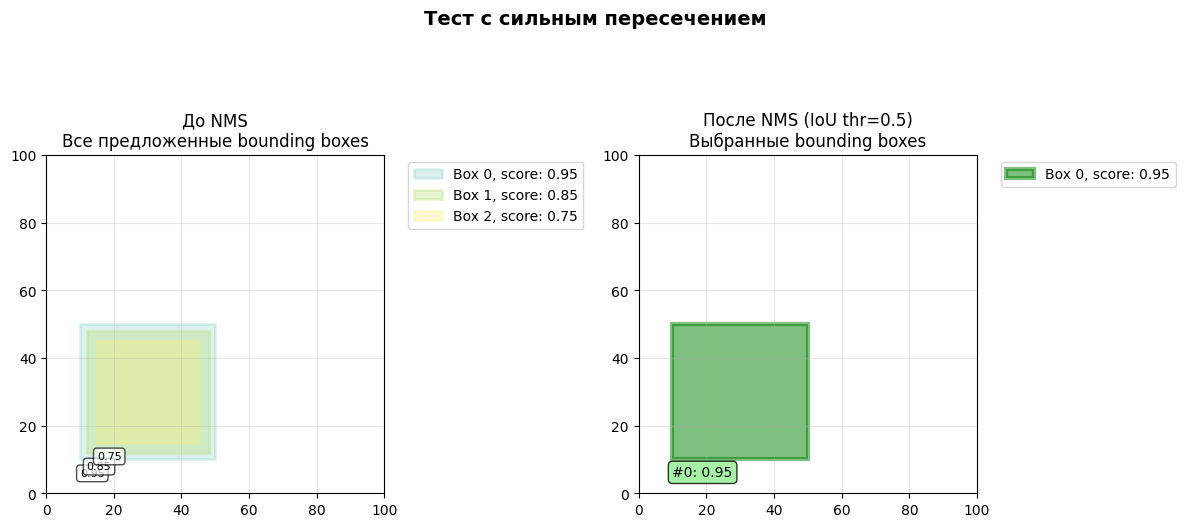

In [ ]:
#тест, где все боксы  сильно пересекаются
def test_high_overlap():
    boxes = [
        [10, 10, 50, 50],
        [12, 12, 48, 48],
        [15, 15, 45, 45],
    ]

    scores = [0.95, 0.85, 0.75]

    selected = non_max_suppression(boxes, scores, iou_threshold=0.5)

    print(f"Полученный результат: {selected}")

    # Проверим IoU
    print("\nIoU между боксами:")
    print(f"Box 0 & Box 1: {calculate_iou(boxes[0], boxes[1]):.3f}")
    print(f"Box 0 & Box 2: {calculate_iou(boxes[0], boxes[2]):.3f}")
    print(f"Box 1 & Box 2: {calculate_iou(boxes[1], boxes[2]):.3f}")
    visualize_nms_results(boxes, scores, selected, "Тест с сильным пересечением")

test_high_overlap()

## **2. Обнаружение объектов с помощью предобученной модели**

In [ ]:
# 2(a) Выбор и загрузка предобученной модели

def load_faster_rcnn_model():
    print("Загрузка модели Faster R-CNN")
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    model.eval()

    print("Модель Faster R-CNN успешно загружена!")
    return model

# Загружаем модель
model = load_faster_rcnn_model()

Загрузка модели Faster R-CNN


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 125MB/s]


Модель Faster R-CNN успешно загружена!


In [ ]:
# метки классов COCO
def get_coco_labels():

    COCO_INSTANCE_CATEGORY_NAMES = [
        '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
        'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
        'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
        'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
        'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
        'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
        'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
        'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut',
        'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
        'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
        'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
        'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
    ]
    return COCO_INSTANCE_CATEGORY_NAMES

coco_labels = get_coco_labels()
print(f"Загружены метки {len(coco_labels)} классов COCO")

Загружены метки 91 классов COCO


## 2(b) Загрузка тестовых изображений из открытых датасетов COCO

In [ ]:
# 2(b) Загрузка тестовых изображений из открытых датасетов COCO

def download_coco_sample_images():
    # URL примеров изображений из COCO dataset
    coco_image_urls = [
        "http://images.cocodataset.org/val2017/000000039769.jpg",
        "http://images.cocodataset.org/val2017/000000037777.jpg",
        "http://images.cocodataset.org/val2017/000000000285.jpg",
        "http://images.cocodataset.org/val2017/000000000724.jpg",
    ]

    images = []
    successful_downloads = 0

    for i, url in enumerate(coco_image_urls):
        try:
            print(f"Загрузка изображения {i+1}...")
            image = load_image_from_url(url)
            images.append(image)
            successful_downloads += 1
            print(f"Изображение {i+1} загружено: {image.size}")
        except Exception as e:
            print(f" Ошибка загрузки изображения {i+1}: {e}")
    return images

test_images   = download_coco_sample_images()

Загрузка изображения 1...
Изображение 1 загружено: (640, 480)
Загрузка изображения 2...
Изображение 2 загружено: (352, 230)
Загрузка изображения 3...
Изображение 3 загружено: (586, 640)
Загрузка изображения 4...
Изображение 4 загружено: (375, 500)


In [ ]:
# Функция для предобработки изображений и выполнения детекции
def preprocess_image(image):
    transform = T.Compose([
        T.ToTensor(),  # Конвертируем в тензор и нормализуем в [0, 1]
    ])
    return transform(image).unsqueeze(0)
# Выполняет обнаружение объектов на нескольких изображениях
def detect_objects_on_images(model, images, confidence_threshold=0.5):

    all_results = []

    for i, image in enumerate(images):
        print(f"\nОбработка изображения {i+1}...")

        # Предобрабатываем изображение
        image_tensor = preprocess_image(image)

        # Выполняем предсказание
        with torch.no_grad():
            predictions = model(image_tensor)

        # Извлекаем результаты
        boxes = predictions[0]['boxes'].cpu().numpy()
        labels = predictions[0]['labels'].cpu().numpy()
        scores = predictions[0]['scores'].cpu().numpy()

        # Фильтруем по порогу уверенности
        keep_indices = scores >= confidence_threshold
        filtered_boxes = boxes[keep_indices]
        filtered_labels = labels[keep_indices]
        filtered_scores = scores[keep_indices]

        # Сохраняем результаты
        result = {
            'boxes': filtered_boxes,
            'labels': filtered_labels,
            'scores': filtered_scores
        }
        all_results.append(result)

        # Выводим статистику
        print(f"  Обнаружено объектов: {len(filtered_boxes)}")
        for j, (label, score) in enumerate(zip(filtered_labels, filtered_scores)):
            if j < 5:  # Показываем первые 5 объектов
                print(f"    - {coco_labels[label]}: {score:.3f}")

    return all_results

# Выполняем обнаружение объектов на всех тестовых изображениях
detection_results = detect_objects_on_images(model, test_images, confidence_threshold=0.5)


Обработка изображения 1...
  Обнаружено объектов: 7
    - cat: 0.989
    - remote: 0.979
    - cat: 0.953
    - remote: 0.781
    - couch: 0.541
    ... и еще 2 объектов

Обработка изображения 2...
  Обнаружено объектов: 17
    - refrigerator: 0.994
    - oven: 0.989
    - banana: 0.963
    - dining table: 0.905
    - orange: 0.904
    ... и еще 12 объектов

Обработка изображения 3...
  Обнаружено объектов: 1
    - bear: 0.993

Обработка изображения 4...
  Обнаружено объектов: 4
    - stop sign: 1.000
    - truck: 0.985
    - stop sign: 0.985
    - truck: 0.501


## 2(c) Визуализация результатов работы детектора

Визуализация результатов детекции


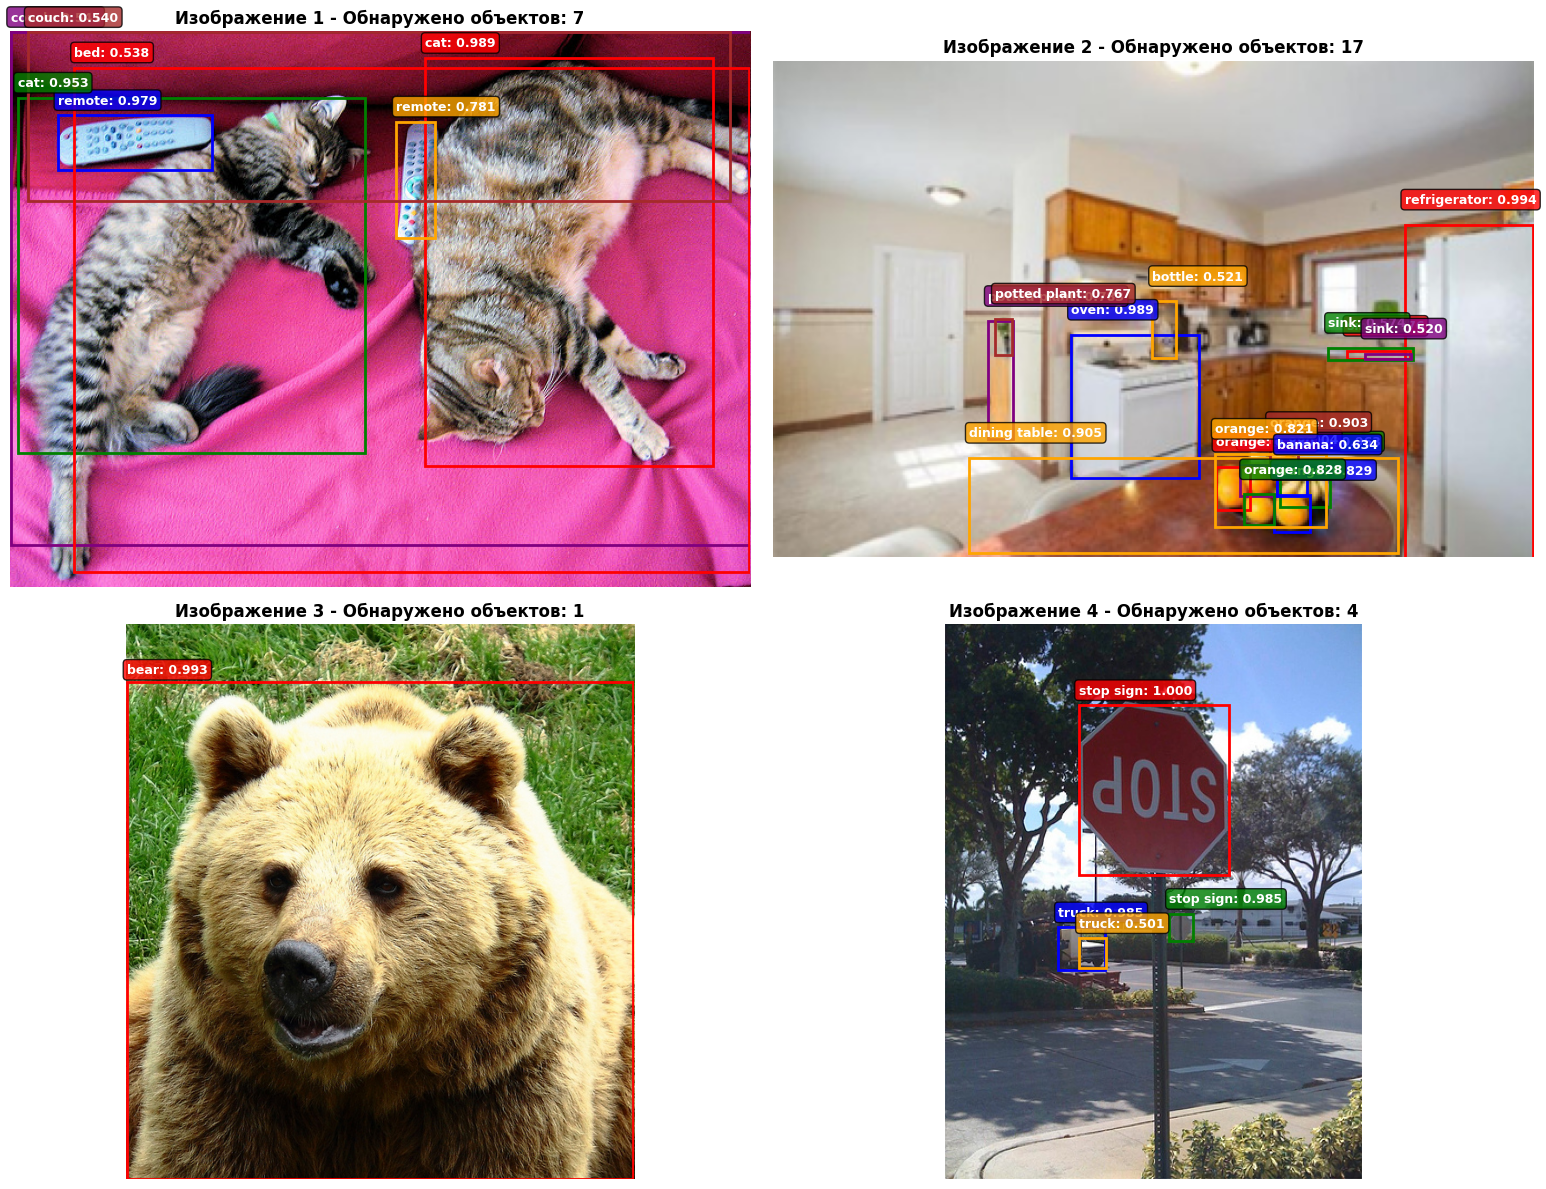

In [ ]:
# 2(c) Визуализация результатов работы детектора

def visualize_detections(images, detection_results, coco_labels):
    print("Визуализация результатов детекции")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    for i, (image, result) in enumerate(zip(images, detection_results)):
        # исходное изображение
        axes[i].imshow(image)

        # результаты детекции для этого изображения
        boxes = result['boxes']
        labels = result['labels']
        scores = result['scores']

        # bounding boxes и подписи
        colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

        for j, (box, label, score) in enumerate(zip(boxes, labels, scores)):
            # Извлекаем координаты bounding box
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1

            # цвет для bounding box
            color = colors[j % len(colors)]

            # Рисуем bounding box
            rect = plt.Rectangle((x1, y1), width, height,fill=False, edgecolor=color, linewidth=2)
            axes[i].add_patch(rect)

            # подпись с классом и уверенностью
            label_text = f"{coco_labels[label]}: {score:.3f}"

            # подпись над bounding box
            axes[i].text(x1, y1-10, label_text, bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.8), fontsize=9, color='white', fontweight='bold')


        axes[i].set_title(f"Изображение {i+1} - Обнаружено объектов: {len(boxes)}",
                         fontsize=12, fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
visualize_detections(test_images, detection_results, coco_labels)

РЕЗУЛЬТАТЫ ВИЗУАЛИЗАЦИИ
* Изображение 1: Коты на диване - обнаружены коты, пульты, диван
* Изображение 2: Кухня - обнаружены холодильник, духовка, фрукты, стол
* Изображение 3: Медведь - обнаружен один объект-медведь
* Изображение 4: Улица - обнаружены знаки остановки и грузовик

In [ ]:
def verify_model_correctness(images, detection_results, coco_labels):

    for i, (image, result) in enumerate(zip(images, detection_results)):
        boxes = result['boxes']
        labels = result['labels']
        scores = result['scores']

        print(f"\n--- Анализ изображения {i+1} ---")
        print(f"Всего обнаружено объектов: {len(boxes)}")

        # Анализируем обнаруженные объекты
        high_confidence_objects = []
        unique_classes = set()

        for box, label, score in zip(boxes, labels, scores):
            class_name = coco_labels[label]
            unique_classes.add(class_name)

            if score > 0.7:  # Высокая уверенность
                high_confidence_objects.append((class_name, score))

        print(f"Уникальные классы: {', '.join(unique_classes)}")
        print(f"Объекты с высокой уверенностью (>0.7): {len(high_confidence_objects)}")

        if len(high_confidence_objects) > 0:
            print("объекты с высокой уверенностью")
            for obj, score in high_confidence_objects[:3]:  # Показываем первые 3
                print(f"   - {obj}: {score:.3f}")
        else:
            print("Нет объектов с высокой уверенностью")

# Проверяем корректность работы модели
verify_model_correctness(test_images, detection_results, coco_labels)


--- Анализ изображения 1 ---
Всего обнаружено объектов: 7
Уникальные классы: bed, couch, remote, cat
Объекты с высокой уверенностью (>0.7): 4
объекты с высокой уверенностью
   - cat: 0.989
   - remote: 0.979
   - cat: 0.953

--- Анализ изображения 2 ---
Всего обнаружено объектов: 17
Уникальные классы: dining table, bottle, refrigerator, banana, oven, orange, sink, potted plant
Объекты с высокой уверенностью (>0.7): 12
объекты с высокой уверенностью
   - refrigerator: 0.994
   - oven: 0.989
   - banana: 0.963

--- Анализ изображения 3 ---
Всего обнаружено объектов: 1
Уникальные классы: bear
Объекты с высокой уверенностью (>0.7): 1
объекты с высокой уверенностью
   - bear: 0.993

--- Анализ изображения 4 ---
Всего обнаружено объектов: 4
Уникальные классы: truck, stop sign
Объекты с высокой уверенностью (>0.7): 3
объекты с высокой уверенностью
   - stop sign: 1.000
   - truck: 0.985
   - stop sign: 0.985


## 2(d) Исследование влияния порога уверенности на результаты детектирования

Исследование влияния порога уверенности 

Изображение 1: Коты на диване 


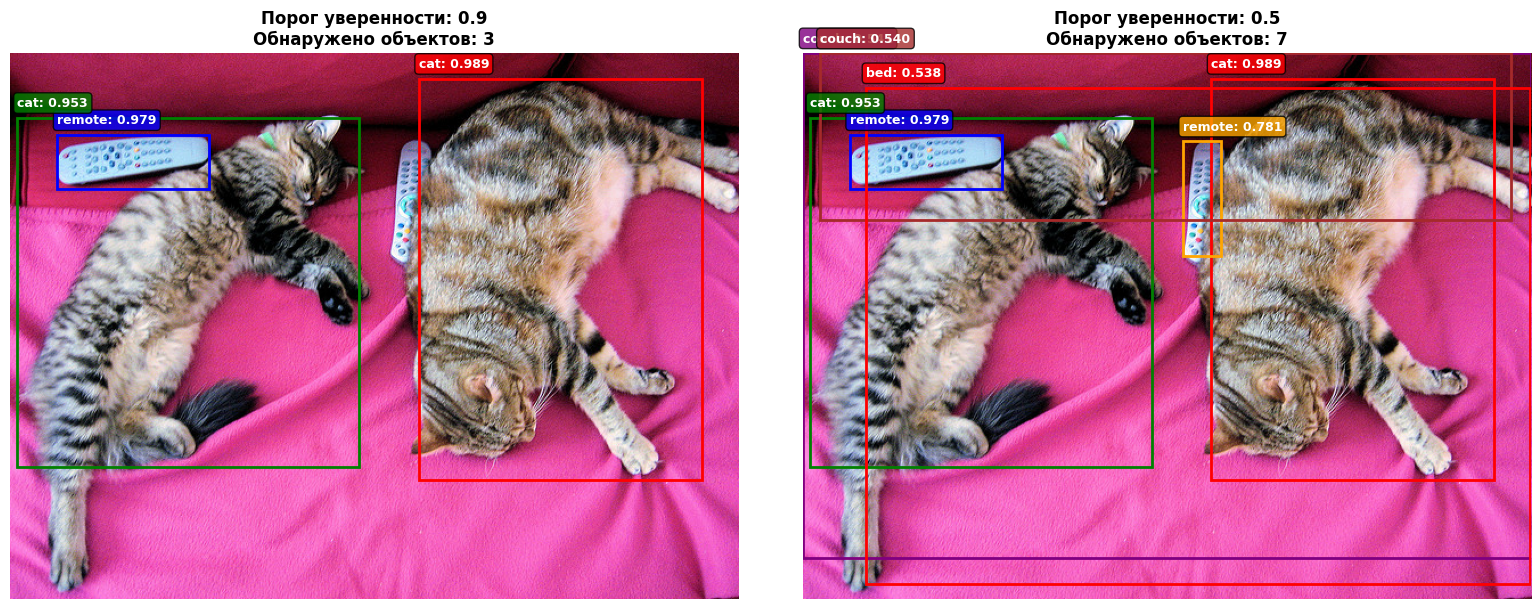


 Изображение 2: Кухня 


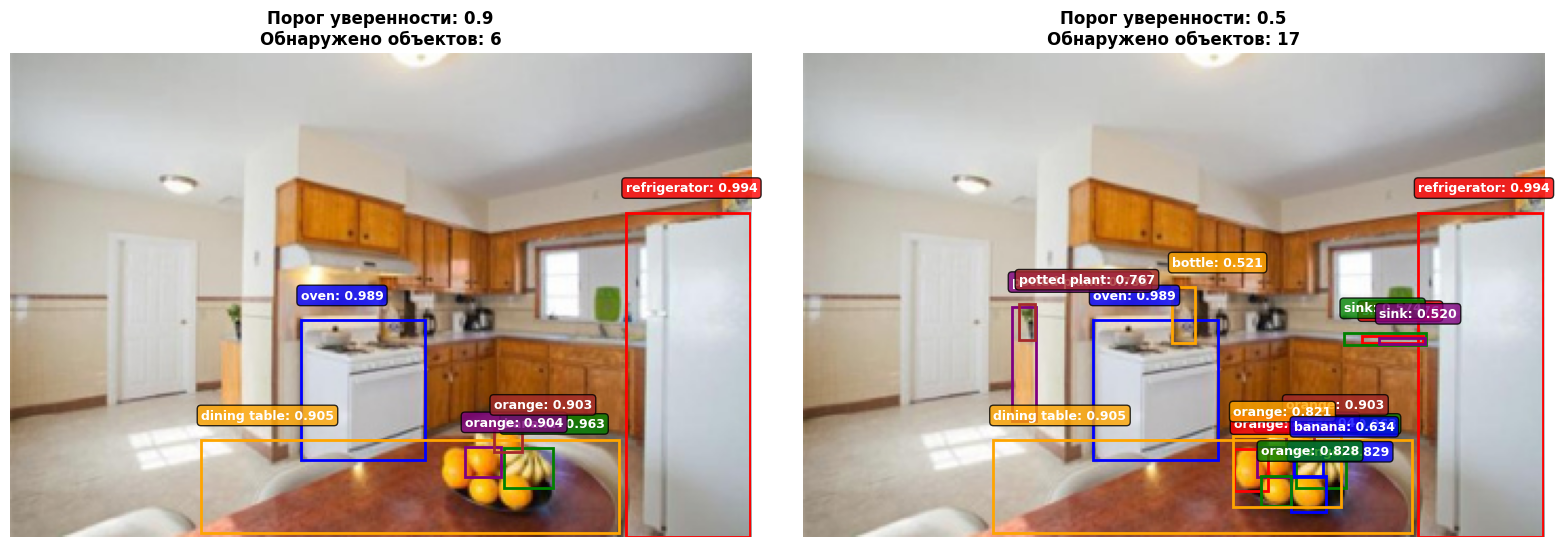

In [ ]:
# Сравнивает результаты детектирования с высоким и низким порогом уверенности
def compare_confidence_thresholds(image, model, coco_labels, thresholds=[0.9, 0.5]):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for idx, threshold in enumerate(thresholds):
        # детектирование с текущим порогом
        image_tensor = preprocess_image(image)
        with torch.no_grad():
            predictions = model(image_tensor)

        boxes = predictions[0]['boxes'].cpu().numpy()
        labels = predictions[0]['labels'].cpu().numpy()
        scores = predictions[0]['scores'].cpu().numpy()

        # Фильтруем по порогу уверенности
        keep_indices = scores >= threshold
        filtered_boxes = boxes[keep_indices]
        filtered_labels = labels[keep_indices]
        filtered_scores = scores[keep_indices]

        # Визуализация
        axes[idx].imshow(image)
        colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

        for j, (box, label, score) in enumerate(zip(filtered_boxes, filtered_labels, filtered_scores)):
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1

            color = colors[j % len(colors)]
            rect = plt.Rectangle((x1, y1), width, height,fill=False, edgecolor=color, linewidth=2)
            axes[idx].add_patch(rect)

            label_text = f"{coco_labels[label]}: {score:.3f}"
            axes[idx].text(x1, y1-10, label_text,  bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.8),fontsize=9, color='white', fontweight='bold')

        axes[idx].set_title(f"Порог уверенности: {threshold}\nОбнаружено объектов: {len(filtered_boxes)}", fontsize=12, fontweight='bold')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    return filtered_boxes, filtered_labels, filtered_scores

print("Исследование влияния порога уверенности ")

# Тестируем на первом изображении (коты на диване)
print("\nИзображение 1: Коты на диване ")
boxes_high, labels_high, scores_high = compare_confidence_thresholds(
    test_images[0], model, coco_labels, thresholds=[0.9, 0.5]
)
print("\n Изображение 2: Кухня ")
boxes_high2, labels_high2, scores_high2 = compare_confidence_thresholds(
    test_images[1], model, coco_labels, thresholds=[0.9, 0.5]
)

In [ ]:
# Анализ изменений при разных порогах
def analyze_threshold_impact(image, model, coco_labels):
    thresholds = [0.9, 0.7, 0.5, 0.3]
    results = {}

    print(f"\nАнализ влияния порога уверенности:")
    print("Порог | Объектов")
    print("-" * 65)

    for threshold in thresholds:
        # Выполняем детектирование
        image_tensor = preprocess_image(image)
        with torch.no_grad():
            predictions = model(image_tensor)

        boxes = predictions[0]['boxes'].cpu().numpy()
        labels = predictions[0]['labels'].cpu().numpy()
        scores = predictions[0]['scores'].cpu().numpy()

        # Фильтруем по порогу
        keep_indices = scores >= threshold
        filtered_boxes = boxes[keep_indices]
        filtered_labels = labels[keep_indices]
        filtered_scores = scores[keep_indices]

        # Анализируем результаты
        high_confidence_objects = len([s for s in scores if s >= 0.7])
        current_detections = len(filtered_boxes)

        results[threshold] = {
            'detections': current_detections,
        }

        print(f"{threshold}    | {current_detections:^8}")

    return results

print("Детальный анализ для изображения 1 ")
threshold_analysis = analyze_threshold_impact(test_images[0], model, coco_labels)
print("Детальный анализ для изображения 2 ")
threshold_analysis = analyze_threshold_impact(test_images[0], model, coco_labels)

Детальный анализ для изображения 1 

Анализ влияния порога уверенности:
Порог | Объектов
-----------------------------------------------------------------
0.9    |    3    
0.7    |    4    
0.5    |    7    
0.3    |    7    
Детальный анализ для изображения 2 

Анализ влияния порога уверенности:
Порог | Объектов
-----------------------------------------------------------------
0.9    |    3    
0.7    |    4    
0.5    |    7    
0.3    |    7    


## Анлиз порогов

Высокий порог (0.9): Обнаруживаются только самые уверенные объекты, могут пропускаться слабые или частично видимые объекты

на изображении с котами остаются только самые уверенные детекции

Низкий порог (0.5):Обнаруживается больше объектов, выше вероятность обнаружения слабых и частичных объектов**

 на кухне обнаруживаются все объекты, включая менее уверенные


**Выбор порога зависит от задачи:**
Для точных детекций: высокий порог (0.7-0.9), для максимального покрытия: низкий порог (0.3-0.5), баланс: средний порог (0.5-0.7)

## **3. Семантическая vs. поэкземплярная сегментация**

In [ ]:
# 3(a) Выбор предобученных моделей для семантической и поэкземплярной сегментации

def load_segmentation_models():
    print("Загрузка моделей для сегментации ")
    semantic_model = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=True)
    semantic_model.eval()
    print(" DeepLabv3 загружен (обучен на COCO)")

    instance_model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
    instance_model.eval()
    print("Mask R-CNN загружен (обучен на COCO)")

    return semantic_model, instance_model

semantic_model, instance_model = load_segmentation_models()

Загрузка моделей для сегментации 


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:02<00:00, 60.8MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


 DeepLabv3 загружен (обучен на COCO)
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:03<00:00, 53.9MB/s]


Mask R-CNN загружен (обучен на COCO)


In [ ]:
def prepare_segmentation_images():

    # Выбираем изображения с несколькими объектами одного класса
    segmentation_image_urls = [
        "http://images.cocodataset.org/val2017/000000000285.jpg",
        "http://images.cocodataset.org/val2017/000000037777.jpg",
        "http://images.cocodataset.org/val2017/000000000724.jpg",
    ]

    seg_images = []

    for i, url in enumerate(segmentation_image_urls):
        try:
            print(f"Загрузка изображения {i+1}...")
            response = requests.get(url, timeout=10)
            image = Image.open(BytesIO(response.content)).convert("RGB")
            seg_images.append(image)
            print(f"Изображение {i+1} загружено: {image.size}")
        except Exception as e:
            print(f"Ошибка загрузки изображения {i+1}: {e}")


    return seg_images
segmentation_images = prepare_segmentation_images()

Загрузка изображения 1...
Изображение 1 загружено: (586, 640)
Загрузка изображения 2...
Изображение 2 загружено: (352, 230)
Загрузка изображения 3...
Изображение 3 загружено: (375, 500)


In [ ]:
# метки классов для сегментации COCO
def get_coco_segmentation_labels():
    COCO_SEGMENTATION_LABELS = [
        '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
        'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
        'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
        'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie',
        'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
        'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass',
        'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
        'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
        'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote',
        'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
        'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
    ]
    return COCO_SEGMENTATION_LABELS

coco_seg_labels = get_coco_segmentation_labels()
print(f"Загружены метки {len(coco_seg_labels)} классов для сегментации COCO")

Загружены метки 81 классов для сегментации COCO


## 3(b) Применение моделей сегментации к изображениям

In [ ]:
# 3(b) Применение моделей сегментации к изображениям
#Применяет семантическую сегментацию к изображению
# Возвращает карту классов (mask)

def apply_semantic_segmentation(model, image):
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(image).unsqueeze(0)

    # Выполнение предсказания
    with torch.no_grad():
        output = model(input_tensor)['out'][0]

    # Получаем карту классов
    semantic_mask = output.argmax(0).byte().cpu().numpy()
    return semantic_mask
#Применяет поэкземплярную сегментацию к изображению
# Возвращает маски и bounding boxes для каждого объекта

def apply_instance_segmentation(model, image):
    transform = T.Compose([T.ToTensor()])
    input_tensor = transform(image).unsqueeze(0)

    # Выполнение предсказания
    with torch.no_grad():
        predictions = model(input_tensor)[0]

    # Извлекаем маски, bounding boxes и метки
    masks = predictions['masks'].cpu().numpy()
    boxes = predictions['boxes'].cpu().numpy()
    labels = predictions['labels'].cpu().numpy()
    scores = predictions['scores'].cpu().numpy()

    # Фильтруем по уверенности
    confidence_threshold = 0.5
    keep = scores >= confidence_threshold

    return {
        'masks': masks[keep],
        'boxes': boxes[keep],
        'labels': labels[keep],
        'scores': scores[keep]
    }

print("Применение моделей сегментации к изображениям ")
print("\nИзображение 1:")

print("Применяем семантическую сегментацию")
semantic_mask1 = apply_semantic_segmentation(semantic_model, segmentation_images[0])
print(f"Получена карта классов размером: {semantic_mask1.shape}")

# Поэкземплярная сегментация
print("Применяем поэкземплярную сегментацию")
instance_result1 = apply_instance_segmentation(instance_model, segmentation_images[0])
print(f"Обнаружено объектов: {len(instance_result1['masks'])}")
for i, (label, score) in enumerate(zip(instance_result1['labels'], instance_result1['scores'])):
    print(f"  Объект {i+1}: {coco_seg_labels[label]} (уверенность: {score:.3f})")


# Сохраняем результаты для визуализации
segmentation_results = {
    'image1': {
        'image': segmentation_images[0],
        'semantic_mask': semantic_mask1,
        'instance_result': instance_result1
    }
}

Применение моделей сегментации к изображениям 

Изображение 1:
Применяем семантическую сегментацию
Получена карта классов размером: (640, 586)
Применяем поэкземплярную сегментацию
Обнаружено объектов: 1
  Объект 1: zebra (уверенность: 0.994)


#№ 3(c) Визуализация результатов сегментации

In [ ]:


def visualize_semantic_segmentation(image, semantic_mask, coco_labels, title):
    # цветовая карта для классов
    unique_classes = np.unique(semantic_mask)
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_classes)))

    # цветная маска
    colored_mask = np.zeros((*semantic_mask.shape, 3))
    for i, class_id in enumerate(unique_classes):
        if class_id < len(coco_labels):
            colored_mask[semantic_mask == class_id] = colors[i][:3]

    # Визуализация
    plt.figure(figsize=(12, 8))

    # Исходное изображение
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Исходное изображение", fontsize=12, fontweight='bold')
    plt.axis('off')

    # Наложение маски на изображение
    plt.subplot(1, 2, 2)
    plt.imshow(image)
    plt.imshow(colored_mask, alpha=0.6)
    plt.title(f"{title}\nСемантическая сегментация", fontsize=12, fontweight='bold')
    plt.axis('off')

    # Легенда с классами
    legend_elements = []
    for i, class_id in enumerate(unique_classes):
        if class_id < len(coco_labels) and class_id != 0:
            legend_elements.append(plt.Rectangle((0, 0), 1, 1, fc=colors[i], label=coco_labels[class_id]))

    if legend_elements:
        plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()
# Визуализирует результаты поэкземплярной сегментации
def visualize_instance_segmentation(image, instance_result, coco_labels, title):
    masks = instance_result['masks']
    boxes = instance_result['boxes']
    labels = instance_result['labels']

    plt.figure(figsize=(12, 8))

    # Исходное изображение
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Исходное изображение", fontsize=12, fontweight='bold')
    plt.axis('off')

    # Результаты instance-сегментации
    plt.subplot(1, 2, 2)
    plt.imshow(image)

    # Цвета для разных объектов
    colors = plt.cm.tab10(np.linspace(0, 1, len(masks)))

    for i, (mask, box, label, color) in enumerate(zip(masks, boxes, labels, colors)):
        # маскf с прозрачностью
        colored_mask = np.zeros((*mask.shape[1:], 4))
        colored_mask[mask[0] > 0.5] = color

        plt.imshow(colored_mask, alpha=0.6)

        # bounding box
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        rect = plt.Rectangle((x1, y1), width, height,fill=False, edgecolor=color, linewidth=2)
        plt.gca().add_patch(rect)
        plt.text(x1, y1-10, f"{coco_labels[label]}",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.8),
                fontsize=9, color='white', fontweight='bold')

    plt.title(f"{title}\nПоэкземплярная сегментация", fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()



 Изображение 1:


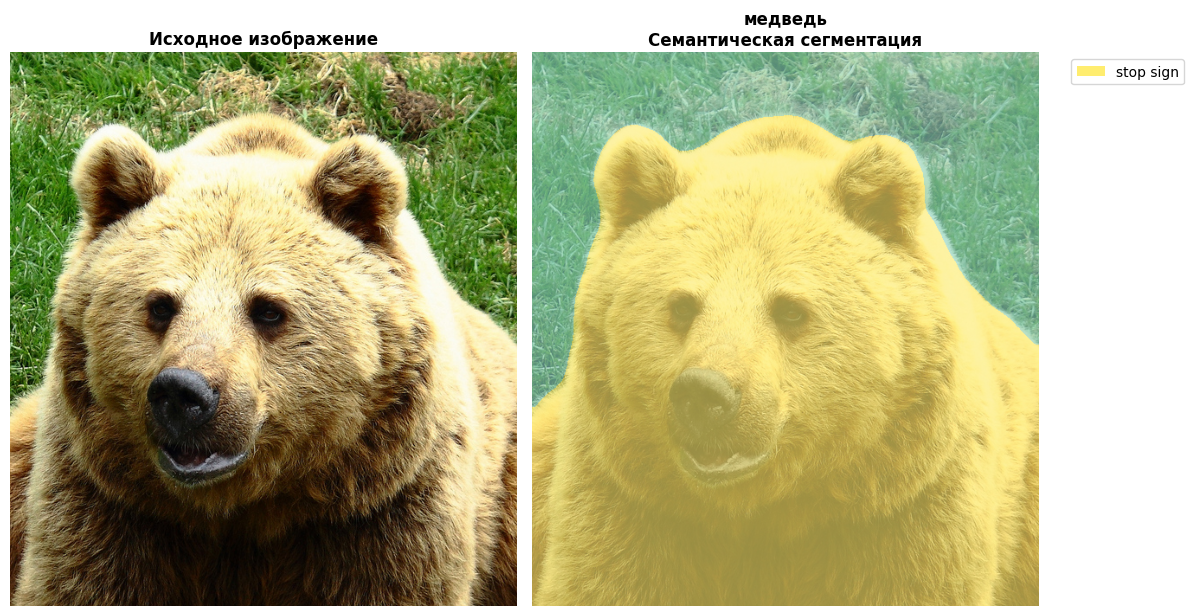

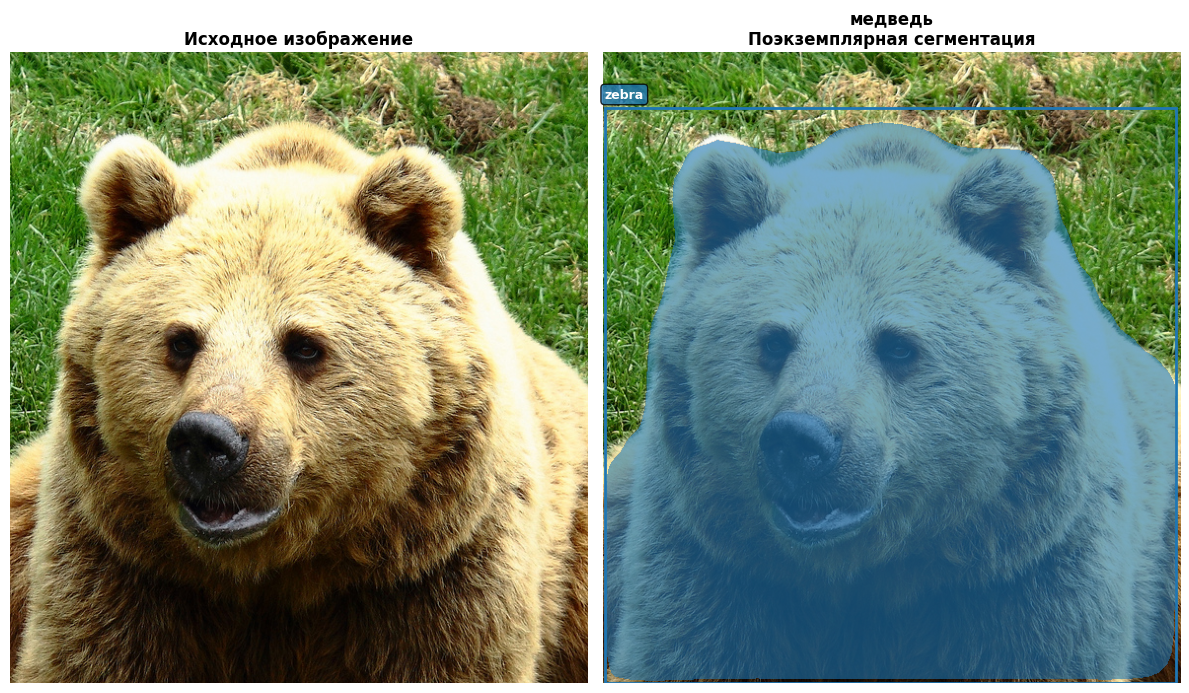

In [ ]:
print("\n Изображение 1:")

# Семантическая сегментация
visualize_semantic_segmentation(
    segmentation_results['image1']['image'],
    segmentation_results['image1']['semantic_mask'],
    coco_seg_labels,
    "медведь"
)

# Поэкземплярная сегментация
visualize_instance_segmentation(
    segmentation_results['image1']['image'],
    segmentation_results['image1']['instance_result'],
    coco_seg_labels,
    "медведь"
)

# Сравнение семантической и поэкземплярной сегментации

**Семантическая сегментация (DeepLabv3)** присваивает класс каждому пикселю изображения, объекты одного класса имеют одинаковый цвет, не различает отдельные экземпляры объектов

**Поэкземплярная сегментация (Mask R-CNN)**:выделяет каждый объект отдельно,разные экземпляры одного класса имеют разные цвета,предоставляет bounding boxes для каждого объекта

## Анализ результатов
Семантическая сегментация:
семантическая сегментация корректно идентифицирует область, принадлежащую классу "медведь", и окрашивает ее в соответствующий цвет.
Поэкземплярная сегментация:
выделяя объект индивидуальной маской и bounding box.


## Почему для поэкземплярной сегментации нужно детектирование
Сначала необходимо обнаружить объекты(bounding boxes),затем для каждого обнаруженного объекта строится маска.Mask R-CNN объединяет Faster R-CNN (детектирование) и FCN (сегментация),без детектирования невозможно разделить перекрывающиеся объекты

## Выводы по эксперименту

Семантическая сегментация подходит для задач, где не важно различать отдельные объекты.

Поэкземплярная сегментация необходима для подсчета объектов,задач, где важны границы между объектами.Оба метода имеют свои применения, выбор зависит от конкретной задачи
